# CMS General Payments EDA

This script returns EDA vizes and summary stats for the General Payments Dataset

This script requires cms_general_payments_clean.csv and leie_with_valid_npi_clean.csv

In [1]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re

def to_snake_case(name: str) -> str:
    # Add underscore between lower-to-upper transitions
    name = re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', name)
    name = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', name)

    # Replace non-alphanumeric with underscores
    name = re.sub(r'[^0-9a-zA-Z]+', '_', name)

    # Remove leading/trailing underscores and lowercase
    return name.strip("_").lower()

In [4]:
# Load the Data
df = pd.read_csv("/dsa/groups/casestudycf25/team02/cms_general_payments_clean.csv", dtype=str)
# df = pd.read_csv("raw_data/cms_general_payments_clean.csv", dtype=str)
df

,Unnamed: 0,change_type,covered_recipient_type,teaching_hospital_ccn,teaching_hospital_id,teaching_hospital_name,covered_recipient_profile_id,covered_recipient_npi,covered_recipient_first_name,covered_recipient_middle_name,...,associated_drug_or_biological_ndc_4,associated_device_or_medical_supply_pdi_4,covered_or_noncovered_indicator_5,indicate_drug_or_biological_or_device_or_medical_supply_5,product_category_or_therapeutic_area_5,name_of_drug_or_biological_or_device_or_medical_supply_5,associated_drug_or_biological_ndc_5,associated_device_or_medical_supply_pdi_5,program_year,payment_publication_date
0,0,UNCHANGED,Covered Recipient Physician,NaN,NaN,NaN,294069,1497734156,CARROLL,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2025-06-30
1,1,UNCHANGED,Covered Recipient Physician,NaN,NaN,NaN,294069,1497734156,CARROLL,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2025-06-30
2,2,UNCHANGED,Covered Recipient Physician,NaN,NaN,NaN,294069,1497734156,CARROLL,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2025-06-30
3,3,UNCHANGED,Covered Recipient Physician,NaN,NaN,NaN,294069,1497734156,CARROLL,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2025-06-30
4,4,UNCHANGED,Covered Recipient Physician,NaN,NaN,NaN,11322702,1932840923,CLAYTON,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,2025-06-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7854703,7854703,UNCHANGED,Covered Recipient Physician,NaN,NaN,NaN,1383906,1447575402,JOSEPH,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,2025-06-30
7854704,7854704,UNCHANGED,Covered Recipient Non-Physician Practitioner,NaN,NaN,NaN,10430847,1336509785,ANNE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,2025-06-30
7854705,7854705,UNCHANGED,Covered Recipient Non-Physician Practitioner,NaN,NaN,NaN,10953697,1164482899,LINDA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,2025-06-30
7854706,7854706,UNCHANGED,Covered Recipient Physician,NaN,NaN,NaN,1025509,1285699512,CYNTHIA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,2025-06-30


In [5]:
special_types = {
    "program_year": "Int64",   # Pandas nullable integer
    "number_of_payments_included_in_total_amount": "Int64",
    "covered_recipient_npi": "Int64",
    "total_amount_of_payment_us_dollars": "float64",
    "payment_publication_date": "datetime64[ns]",
    "date_of_payment": "datetime64[ns]",
}

In [6]:
for col, dtype in special_types.items():
    if dtype == "datetime64[ns]":
        df[col] = pd.to_datetime(df[col], errors = "coerce")

    elif dtype == "Int64":
        df[col] = pd.to_numeric(df[col], errors = "coerce").astype("Int64")

    elif dtype == "float64":
        df[col] = pd.to_numeric(df[col], errors = "coerce")

    else:
        df[col] = df[col].astype(dtype)

In [7]:
#####################
# Drop unrelated columns
#####################
drops_cols = [
    'covered_recipient_first_name', 'covered_recipient_middle_name', #unnecessary to have name
    'teaching_hospital_ccn', 'teaching_hospital_id', 'teaching_hospital_name', #no teaching hospitals
    'covered_recipient_last_name', 'covered_recipient_name_suffix', 
     'recipient_province',
    'covered_recipient_primary_type_2','covered_recipient_primary_type_3', 'covered_recipient_specialty_2', # mostly blank
    'related_product_indicator','delay_in_publication_indicator', #only Nos so remove
     'associated_drug_or_biological_ndc_1', 'associated_drug_or_biological_ndc_2', # remove unrelated drug info
    'associated_drug_or_biological_ndc_3','associated_drug_or_biological_ndc_4', 'associated_drug_or_biological_ndc_5',
    'submitting_applicable_manufacturer_or_applicable_gpo_name' # mostly the same as applicable manufacturer name
]

In [8]:
df.drop(columns = drops_cols, inplace = True) # drop blank columns

In [9]:
# Filter all non-physician practitioners

df = df[df["covered_recipient_type"] != "Covered Recipient Non-Physician Practitioner"].copy()

In [10]:
mapping = {
    'Charitable Contribution': 'Charity',
    'Entertainment': 'Entertainment',
    'Debt forgiveness': 'Debt Forgiveness',
    'Current or prospective ownership or investment interest': 'Ownership or Investment',
    'Compensation for serving as faculty or as a speaker for a medical education program': 'Faculty or Speaker',
    'Education': 'Education',
    'Acquisitions': 'Acquisition',
    'Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program': 'Other Services',
    'Food and Beverage': 'Food and Beverage',
    'Consulting Fee': 'Consulting'
}

df['nature_short_descr'] = df['nature_of_payment_or_transfer_of_value'].map(mapping)


In [11]:
# U.S. Census Bureau 4-Region Mapping
# Region 1 = Northeast
# Region 2 = Midwest
# Region 3 = South
# Region 4 = West

# U.S. Census Bureau 4-Region Mapping (Region Names)

census_region_map = {
    # --- Northeast ---
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast",
    "NH": "Northeast", "RI": "Northeast", "VT": "Northeast",
    "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

    # --- Midwest ---
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest",
    "OH": "Midwest", "WI": "Midwest",
    "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
    "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",

    # --- South ---
    # South Atlantic
    "DE": "South", "DC": "South", "FL": "South", "GA": "South",
    "MD": "South", "NC": "South", "SC": "South", "VA": "South", "WV": "South",
    # East South Central
    "AL": "South", "KY": "South", "MS": "South", "TN": "South",
    # West South Central
    "AR": "South", "LA": "South", "OK": "South", "TX": "South",

    # --- West ---
    # Mountain
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
    "NM": "West", "UT": "West", "WY": "West",
    # Pacific
    "AK": "West", "CA": "West", "HI": "West", "OR": "West", "WA": "West",
}


df['recipient_region'] = df['recipient_state'].map(census_region_map)

In [12]:
df[['recipient_region', 'recipient_state']]

,recipient_region,recipient_state
0,South,NC
1,South,NC
2,South,NC
3,South,NC
4,Midwest,MI
...,...,...
7854700,Northeast,NY
7854701,Northeast,PA
7854702,Northeast,NY
7854703,Midwest,WI


## Add in LEIE

In [13]:
leie = pd.read_csv("/dsa/groups/casestudycf25/team02/leie_with_valid_npi_clean.csv")
# leie = pd.read_csv("raw_data\leie_with_valid_npi_clean.csv")
leie.head()

,general,specialty,npi,excltype,excldate,num_exclusions_alltime,num_exclusion_types_alltime,list_exclusion_types_alltime,num_addresses_alltime,new_id,fraud_flag,excl_1128a1,excl_1128a2,excl_1128a3,excl_1128b5,excl_1128b6,excl_1128b7,excl_brch cia
0,IND- LIC HC SERV PRO,DENTIST,1.861529e+09,1128a3,2024-03-20,1.0,1.0,['1128a3'],1.0,AAMIR-WAHAB-nan-1979-11-16,1,0,0,1,0,0,0,0
1,IND- LIC HC SERV PRO,CHIROPRACTIC,1.366545e+09,1128b7,2021-08-16,1.0,1.0,['1128b7'],1.0,AARON-OXENRIDER-nan-1976-06-07,1,0,0,0,0,0,1,0
2,IND- LIC HC SERV PRO,HEALTH CARE AIDE,1.376215e+09,1128a1,2025-01-20,1.0,1.0,['1128a1'],1.0,AARON-WALTON-nan-1971-11-19,1,1,0,0,0,0,0,0
3,BUS OWNER/EXEC,COUNSELING CENTER,1.326353e+09,1128a1,2022-03-20,1.0,1.0,['1128a1'],1.0,AARON-WILLIAMS-nan-1962-10-20,1,1,0,0,0,0,0,0
4,BUS OWNER/EXEC,ASSISTED LIVING FACI,1.578130e+09,1128a1,2025-07-20,1.0,1.0,['1128a1'],1.0,ABDOULIE-LOWE-nan-1975-12-27,1,1,0,0,0,0,0,0


In [14]:
leie["npi"] = pd.to_numeric(leie["npi"], errors = "coerce").astype("Int64")

In [15]:
df = df.merge(
    leie[["npi", "excltype", "num_exclusions_alltime","num_exclusion_types_alltime","fraud_flag"]], how = "left", left_on = "covered_recipient_npi", right_on = "npi"
)

In [16]:
df.drop(columns = ["npi"], inplace = True) # drop blank columns

In [17]:
df["fraud_flag"] = df["fraud_flag"].fillna(0).astype("Int64")

In [18]:
# Create hierarchy splits
splits = df['covered_recipient_specialty_1'].str.split('|', expand=True)
splits.columns = [f'specialty_lvl{i+1}' for i in range(splits.shape[1])]
df = pd.concat([df, splits], axis=1)

In [24]:
fraud_only = df[df["fraud_flag"] == 1].copy()
no_fraud = df[df["fraud_flag"] != 1].copy()

In [25]:
fraud_only.shape

(1122, 75)

In [26]:
fraud_only.columns

Index(['Unnamed: 0', 'change_type', 'covered_recipient_type',
       'covered_recipient_profile_id', 'covered_recipient_npi',
       'recipient_primary_business_street_address_line1',
       'recipient_primary_business_street_address_line2', 'recipient_city',
       'recipient_state', 'recipient_zip_code', 'recipient_country',
       'recipient_postal_code', 'covered_recipient_primary_type_1',
       'covered_recipient_specialty_1',
       'covered_recipient_license_state_code1',
       'covered_recipient_license_state_code2',
       'covered_recipient_license_state_code3',
       'covered_recipient_license_state_code4',
       'covered_recipient_license_state_code5',
       'applicable_manufacturer_or_applicable_gpo_making_payment_id',
       'applicable_manufacturer_or_applicable_gpo_making_payment_name',
       'applicable_manufacturer_or_applicable_gpo_making_payment_state',
       'applicable_manufacturer_or_applicable_gpo_making_payment_country',
       'total_amount_of_payment_u

In [27]:
# fraud only amounts
fraud_avg_payment =  fraud_only.groupby(["recipient_state"])['total_amount_of_payment_us_dollars'].sum().round(0)

fraud_avg_payment.mean().round(0)

4055.0

In [28]:
# no fraud amounts
no_fraud_avg_payment = no_fraud.groupby(["recipient_state"])['total_amount_of_payment_us_dollars'].sum().round(0)

no_fraud_avg_payment.mean().round(0)

52673130.0

In [29]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['covered_recipient_npi', 'total_amount_of_payment_us_dollars',
       'number_of_payments_included_in_total_amount', 'program_year',
       'num_exclusions_alltime', 'num_exclusion_types_alltime', 'fraud_flag'],
      dtype='object')

In [30]:
df["fraud_flag"].value_counts()

fraud_flag
0    6561748
1       1122
Name: count, dtype: Int64

In [31]:
round(((1122/6561748)*100),3)

0.017

In [32]:
df.groupby(["fraud_flag"])['covered_recipient_npi'].nunique().round(0)

fraud_flag
0    570148
1       136
Name: covered_recipient_npi, dtype: int64

In [33]:
round(((136/570148)*100),3)

0.024

### Specialty Vizes

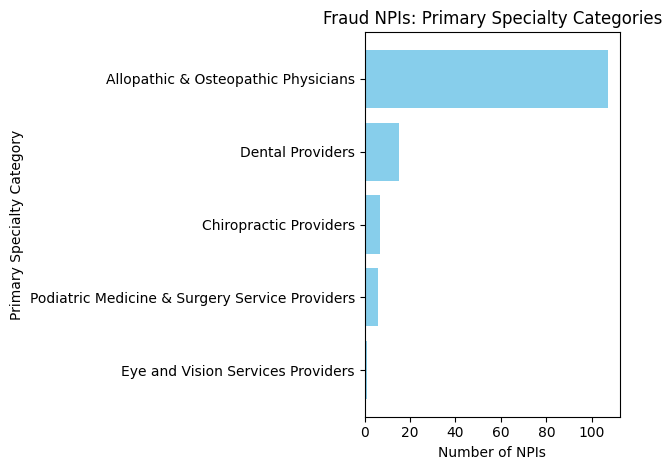

In [34]:
specialty_npi = fraud_only[["covered_recipient_npi", "specialty_lvl1", "program_year"]].copy()

specialty_npi = specialty_npi.sort_values(by="program_year", ascending=False).drop_duplicates(subset = ["covered_recipient_npi"]).copy()

specialties = pd.DataFrame(specialty_npi["specialty_lvl1"].value_counts())

specialties = specialties.head(20)

specialties = specialties.reset_index().rename(columns={"index": "specialty_lvl1", "count": "count"}).sort_values(by="count", ascending=True)

plt.barh(specialties["specialty_lvl1"], specialties["count"], color='skyblue')

plt.xlabel("Number of NPIs")
plt.ylabel("Primary Specialty Category")
plt.title("Fraud NPIs: Primary Specialty Categories")
plt.tight_layout()
plt.show()

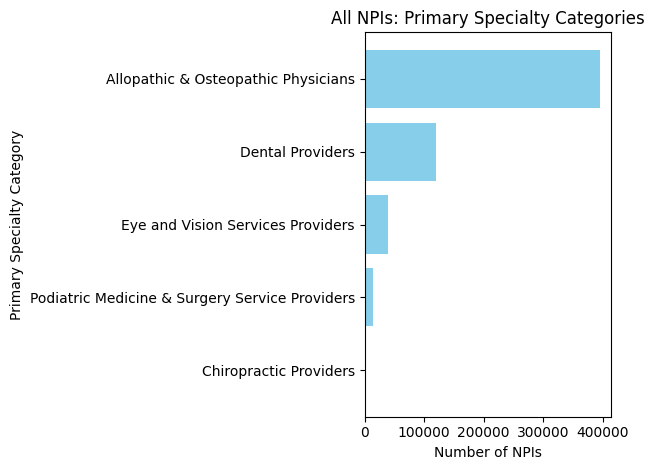

In [35]:
specialty_npi = df[["covered_recipient_npi", "specialty_lvl1", "program_year"]].copy()

specialty_npi = specialty_npi.sort_values(by="program_year", ascending=False).drop_duplicates(subset = ["covered_recipient_npi"]).copy()

specialties = pd.DataFrame(specialty_npi["specialty_lvl1"].value_counts())

specialties = specialties.head(10)

specialties = specialties.reset_index().rename(columns={"index": "specialty_lvl1", "count": "count"}).sort_values(by="count", ascending=True)

plt.barh(specialties["specialty_lvl1"], specialties["count"], color='skyblue')
plt.xlabel("Number of NPIs")
plt.ylabel("Primary Specialty Category")
plt.title("All NPIs: Primary Specialty Categories")
plt.tight_layout()
plt.show()

In [36]:
# Cross tab with mean payment
ct = pd.pivot_table(
    df,
    values='total_amount_of_payment_us_dollars',
    index='specialty_lvl1',
    columns='fraud_flag',
    aggfunc='mean'
)

print(ct)

fraud_flag                                               0           1
specialty_lvl1                                                        
Allopathic & Osteopathic Physicians             545.932388  111.846095
Chiropractic Providers                          187.456115   31.080000
Dental Providers                                226.138926   51.757500
Eye and Vision Services Providers               102.241518   92.510000
Podiatric Medicine & Surgery Service Providers  281.034168  299.922857


In [37]:
only_2023 = df[df["program_year"] == 2023].copy()

only_2023.shape

(2562293, 75)

In [38]:
stats_specialty_lvl1 = df.groupby('specialty_lvl1')['total_amount_of_payment_us_dollars'].quantile([0.25, 0.5, 0.75]).unstack()

stats_specialty_lvl1

,0.25,0.50,0.75
specialty_lvl1,,,
Allopathic & Osteopathic Physicians,16.20,26.26,106.06
Chiropractic Providers,17.35,24.73,88.71
Dental Providers,15.17,26.57,75.00
Eye and Vision Services Providers,15.91,22.58,66.81
Podiatric Medicine & Surgery Service Providers,17.15,29.28,97.91


In [39]:
stats_specialty_lvl2 = df.groupby('specialty_lvl2')['total_amount_of_payment_us_dollars'].quantile([0.25, 0.5, 0.75]).unstack()

stats_specialty_lvl2

,0.25,0.50,0.75
specialty_lvl2,,,
Advanced Practice Dental Therapist,36.9500,47.310,49.5350
Allergy & Immunology,15.3600,19.305,31.2275
Anesthesiology,13.9300,23.650,80.0000
"Assistant, Podiatric",16.6600,30.030,86.1400
Chiropractor,17.3500,24.730,88.7100
Clinical Pharmacology,21.4700,24.800,54569.2450
Colon & Rectal Surgery,19.2300,52.920,174.1000
Dental Assistant,15.0500,18.530,19.2700
Dental Hygienist,37.2150,112.990,299.0700


## Product Vizes

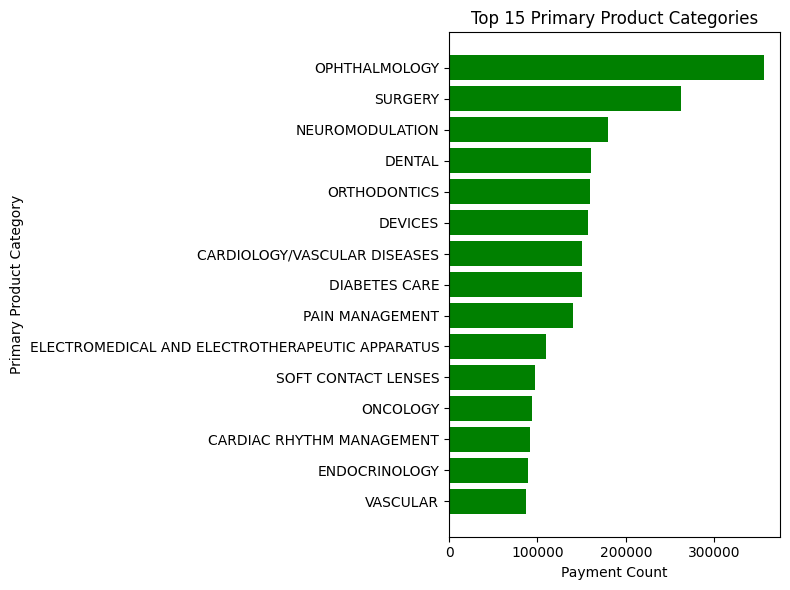

In [40]:
# Group by the column and get counts
products_lvl1 = (
    df.groupby("product_category_or_therapeutic_area_1")
      .size()
      .sort_values(ascending=False)
).head(15).sort_values(ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(products_lvl1.index, products_lvl1.values, color='green')

plt.xlabel("Payment Count")
plt.ylabel("Primary Product Category")
plt.title("Top 15 Primary Product Categories")
plt.tight_layout()
plt.show()

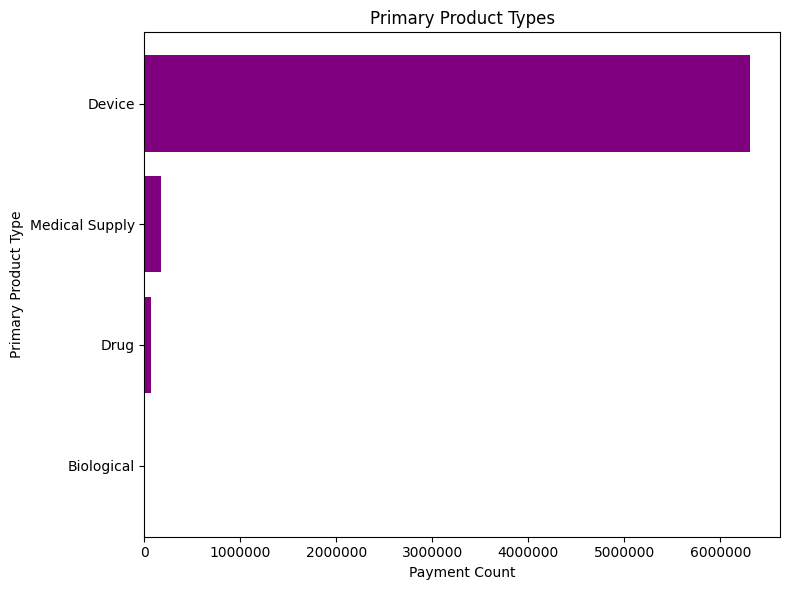

In [41]:
# Group by the column and get counts
products_lvl1 = (
    df.groupby("indicate_drug_or_biological_or_device_or_medical_supply_1")
      .size()
      .sort_values(ascending=True)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(products_lvl1.index, products_lvl1.values, color='purple')

# Remove scientific notation on x-axis
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')

plt.xlabel("Payment Count")
plt.ylabel("Primary Product Type")
plt.title("Primary Product Types")
plt.tight_layout()
plt.show()

### Run Stats on Specialties

In [42]:
# ---- CONFIG ----
label_col = "fraud_flag"
specialty_col = "specialty_lvl1"   
num_features = [
    "total_amount_of_payment_us_dollars"
]

# ---- FUNCTION: Cohen's d ----
def cohens_d(x, y):
    x = x.dropna()
    y = y.dropna()
    
    nx = len(x)
    ny = len(y)
    
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) +
          (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    
    if pooled_std == 0:
        return 0
    
    return (np.mean(x) - np.mean(y)) / pooled_std


# ---- MAIN: Build comparison table by specialty ----
def build_median_diff_by_specialty(df, specialty_col, label_col, num_features):
    results = []

    specialties = df[specialty_col].dropna().unique()

    for spec in specialties:
        sub_df = df[df[specialty_col] == spec]

        fraud_df = sub_df[sub_df[label_col] == 1]
        nonfraud_df = sub_df[sub_df[label_col] == 0]

        for feat in num_features:
            fraud_vals = fraud_df[feat]
            nonfraud_vals = nonfraud_df[feat]

            fraud_med = fraud_vals.median()
            nonfraud_med = nonfraud_vals.median()
            diff = fraud_med - nonfraud_med

            d = cohens_d(fraud_vals, nonfraud_vals)

            results.append({
                "Specialty": spec,
                "Feature": feat,
                "Fraud Median": fraud_med,
                "Non-Fraud Median": nonfraud_med,
                "Difference": diff,
                "Num Fraud Sampled": len(fraud_vals),
                "Num Non Fraud Sampled": len(nonfraud_vals),
                "Class Ratio": len(fraud_vals) / len(nonfraud_vals) if len(nonfraud_vals) != 0 else np.nan, 
                "Effect Size (Cohen's d)": d
            })

    return pd.DataFrame(results)


# ---- RUN ----
summary_table = build_median_diff_by_specialty(df, specialty_col, label_col, num_features)
summary_table

,Specialty,Feature,Fraud Median,Non-Fraud Median,Difference,Num Fraud Sampled,Num Non Fraud Sampled,Class Ratio,Effect Size (Cohen's d)
0,Allopathic & Osteopathic Physicians,total_amount_of_payment_us_dollars,19.000,26.26,-7.260,1032,5208508,0.000198,-0.017165
1,Podiatric Medicine & Surgery Service Providers,total_amount_of_payment_us_dollars,68.265,29.28,38.985,56,268569,0.000209,0.005291
2,Dental Providers,total_amount_of_payment_us_dollars,33.075,26.57,6.505,20,641430,0.000031,-0.042616
3,Eye and Vision Services Providers,total_amount_of_payment_us_dollars,92.510,22.58,69.930,2,438204,0.000005,-0.007881
4,Chiropractic Providers,total_amount_of_payment_us_dollars,16.525,24.74,-8.215,12,5037,0.002382,-0.038403


### Run Stats on State Amounts

In [43]:
# ---- CONFIG ----
label_col = "fraud_flag"
specialty_col = "recipient_state"   
num_features = [
    "total_amount_of_payment_us_dollars"
]

# ---- FUNCTION: Cohen's d ----
def cohens_d(x, y):
    x = x.dropna()
    y = y.dropna()
    
    nx = len(x)
    ny = len(y)
    
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) +
          (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    
    if pooled_std == 0:
        return 0
    
    return (np.mean(x) - np.mean(y)) / pooled_std


# ---- MAIN: Build comparison table by specialty ----
def build_median_diff_by_specialty(df, specialty_col, label_col, num_features):
    results = []

    specialties = df[specialty_col].dropna().unique()

    for spec in specialties:
        sub_df = df[df[specialty_col] == spec]

        fraud_df = sub_df[sub_df[label_col] == 1]
        nonfraud_df = sub_df[sub_df[label_col] == 0]

        for feat in num_features:
            fraud_vals = fraud_df[feat]
            nonfraud_vals = nonfraud_df[feat]

            fraud_med = fraud_vals.median()
            nonfraud_med = nonfraud_vals.median()
            diff = fraud_med - nonfraud_med

            d = cohens_d(fraud_vals, nonfraud_vals)

            results.append({
                "State": spec,
                "Feature": feat,
                "Fraud Median": fraud_med,
                "Non-Fraud Median": nonfraud_med,
                "Difference": diff,
                "Num Fraud Sampled": len(fraud_vals),
                "Num Non Fraud Sampled": len(nonfraud_vals),
                "Class Ratio": len(fraud_vals) / len(nonfraud_vals) if len(nonfraud_vals) != 0 else np.nan, 
                "Effect Size (Cohen's d)": d
            })

    return pd.DataFrame(results)


# ---- RUN ----
summary_table = build_median_diff_by_specialty(df, specialty_col, label_col, num_features)
summary_table

,State,Feature,Fraud Median,Non-Fraud Median,Difference,Num Fraud Sampled,Num Non Fraud Sampled,Class Ratio,Effect Size (Cohen's d)
0,NC,total_amount_of_payment_us_dollars,27.000,25.490,1.510,7,201918,0.000035,-0.057070
1,MI,total_amount_of_payment_us_dollars,16.985,26.900,-9.915,18,209525,0.000086,-0.042773
2,SC,total_amount_of_payment_us_dollars,16.730,21.860,-5.130,3,117160,0.000026,-0.074382
3,PA,total_amount_of_payment_us_dollars,14.920,26.230,-11.310,44,279579,0.000157,-0.027977
4,IL,total_amount_of_payment_us_dollars,22.285,28.330,-6.045,252,263639,0.000956,-0.013330
5,TX,total_amount_of_payment_us_dollars,18.130,24.370,-6.240,166,684421,0.000243,-0.009818
6,CA,total_amount_of_payment_us_dollars,24.810,28.440,-3.630,152,702803,0.000216,-0.018447
7,IN,total_amount_of_payment_us_dollars,38.650,24.400,14.250,4,120278,0.000033,-0.044029
8,OH,total_amount_of_payment_us_dollars,14.585,27.480,-12.895,44,242995,0.000181,-0.052137
9,NY,total_amount_of_payment_us_dollars,23.550,29.630,-6.080,71,400369,0.000177,-0.024245


### Run Stats by Region

In [44]:
# Do above by region
# ---- CONFIG ----
label_col = "fraud_flag"
specialty_col = "recipient_region"   
num_features = [
    "total_amount_of_payment_us_dollars"
]

# ---- FUNCTION: Cohen's d ----
def cohens_d(x, y):
    x = x.dropna()
    y = y.dropna()
    
    nx = len(x)
    ny = len(y)
    
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) +
          (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    
    if pooled_std == 0:
        return 0
    
    return (np.mean(x) - np.mean(y)) / pooled_std


# ---- MAIN: Build comparison table by specialty ----
def build_median_diff_by_specialty(df, specialty_col, label_col, num_features):
    results = []

    specialties = df[specialty_col].dropna().unique()

    for spec in specialties:
        sub_df = df[df[specialty_col] == spec]

        fraud_df = sub_df[sub_df[label_col] == 1]
        nonfraud_df = sub_df[sub_df[label_col] == 0]

        for feat in num_features:
            fraud_vals = fraud_df[feat]
            nonfraud_vals = nonfraud_df[feat]

            fraud_med = fraud_vals.median()
            nonfraud_med = nonfraud_vals.median()
            diff = fraud_med - nonfraud_med

            d = cohens_d(fraud_vals, nonfraud_vals)

            results.append({
                "Region": spec,
                "Feature": feat,
                "Fraud Median": fraud_med,
                "Non-Fraud Median": nonfraud_med,
                "Difference": diff,
                "Num Fraud Sampled": len(fraud_vals),
                "Num Non Fraud Sampled": len(nonfraud_vals),
                "Class Ratio": len(fraud_vals) / len(nonfraud_vals) if len(nonfraud_vals) != 0 else np.nan, 
                "Effect Size (Cohen's d)": d
            })

    return pd.DataFrame(results)


# ---- RUN ----
summary_table = build_median_diff_by_specialty(df, specialty_col, label_col, num_features)
summary_table


,Region,Feature,Fraud Median,Non-Fraud Median,Difference,Num Fraud Sampled,Num Non Fraud Sampled,Class Ratio,Effect Size (Cohen's d)
0,South,total_amount_of_payment_us_dollars,18.20,24.32,-6.12,408,2766166,0.000147,-0.013423
1,Midwest,total_amount_of_payment_us_dollars,18.39,27.40,-9.01,382,1279202,0.000299,-0.018315
2,Northeast,total_amount_of_payment_us_dollars,18.57,28.15,-9.58,141,1102294,0.000128,-0.026539
3,West,total_amount_of_payment_us_dollars,26.89,27.89,-1.00,190,1383987,0.000137,-0.018084


### Nature of Payments Vizes

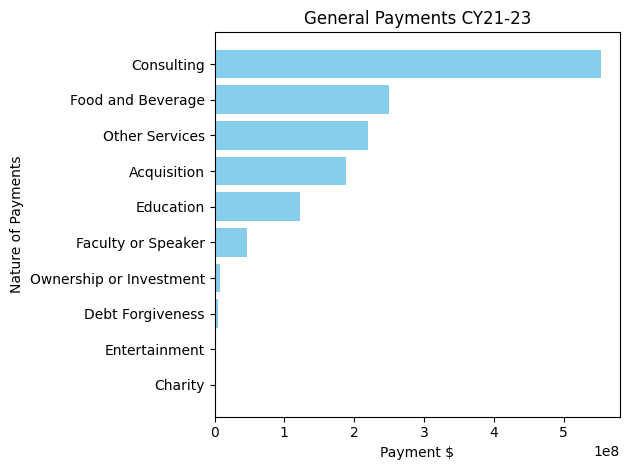

In [45]:
nature_payments = df.groupby("nature_short_descr")["total_amount_of_payment_us_dollars" ].sum()

nature_payments

natures = pd.DataFrame(nature_payments)

natures = natures.head(10)

natures = natures.reset_index().rename(columns={"index": "nature_short_descr", "sum": "total_amount_of_payment_us_dollars"}).sort_values(by="total_amount_of_payment_us_dollars", ascending=True)

plt.barh(natures["nature_short_descr"], natures["total_amount_of_payment_us_dollars"], color='skyblue')


plt.xlabel("Payment $")
plt.ylabel("Nature of Payments")
plt.title("General Payments CY21-23")
plt.tight_layout()
plt.show()

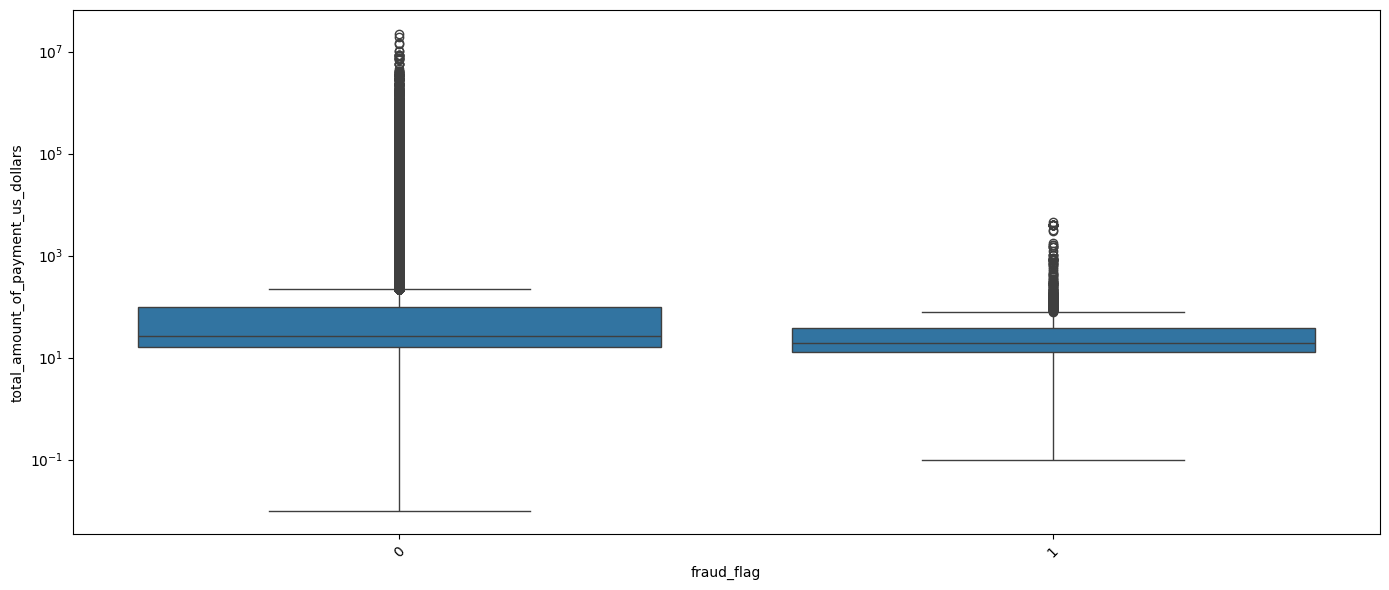

In [47]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x='fraud_flag',
    y='total_amount_of_payment_us_dollars'
)

plt.yscale('log')  # adjusted boxplot with log scaling
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

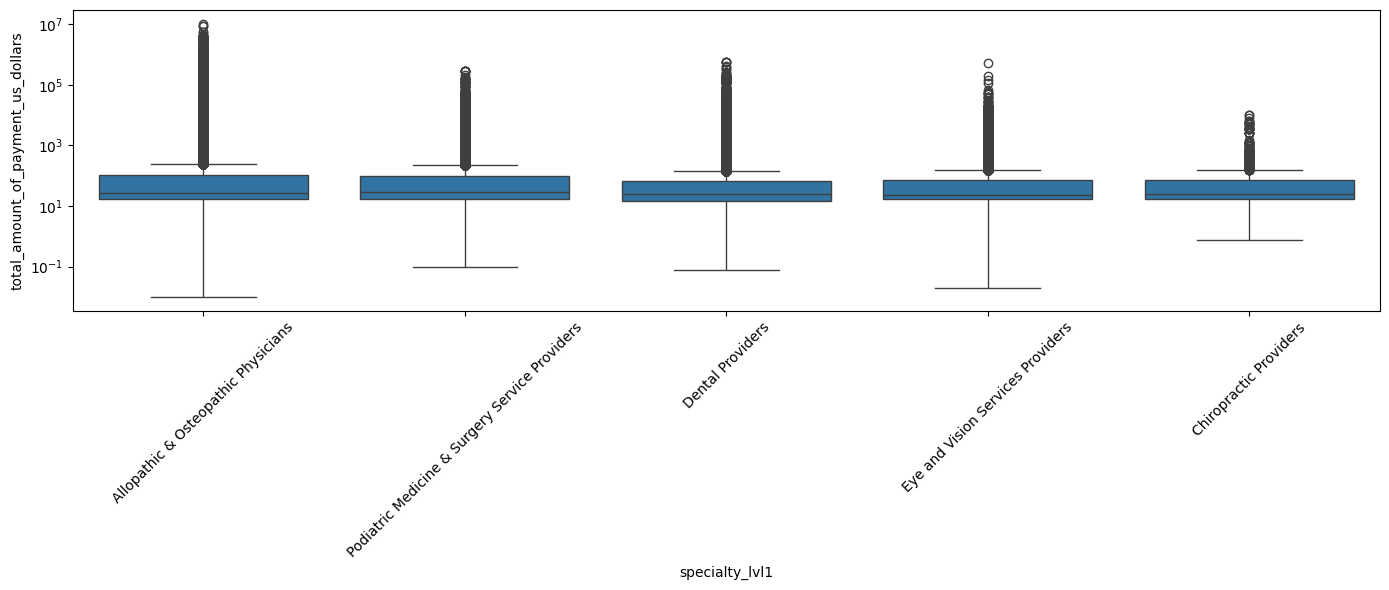

In [48]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=only_2023,
    x='specialty_lvl1',
    y='total_amount_of_payment_us_dollars'
)

plt.yscale('log')  # adjusted boxplot with log scaling
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

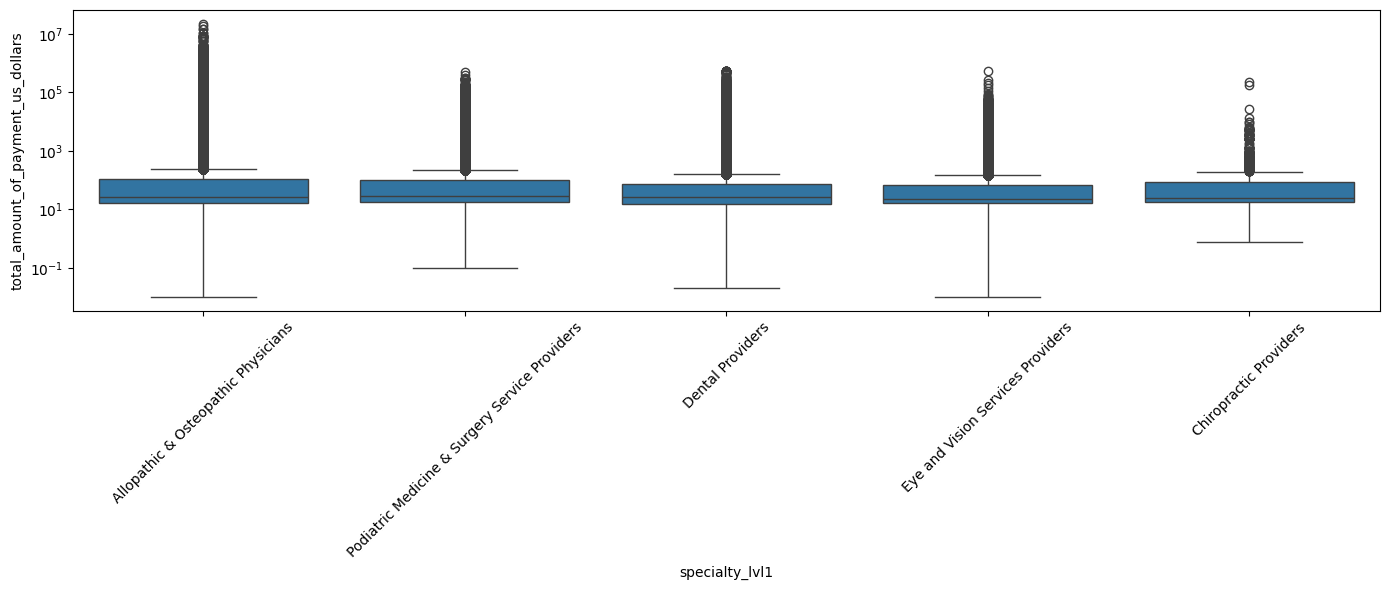

In [49]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x='specialty_lvl1',
    y='total_amount_of_payment_us_dollars'
)

plt.yscale('log')  # adjusted boxplot with log scaling
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

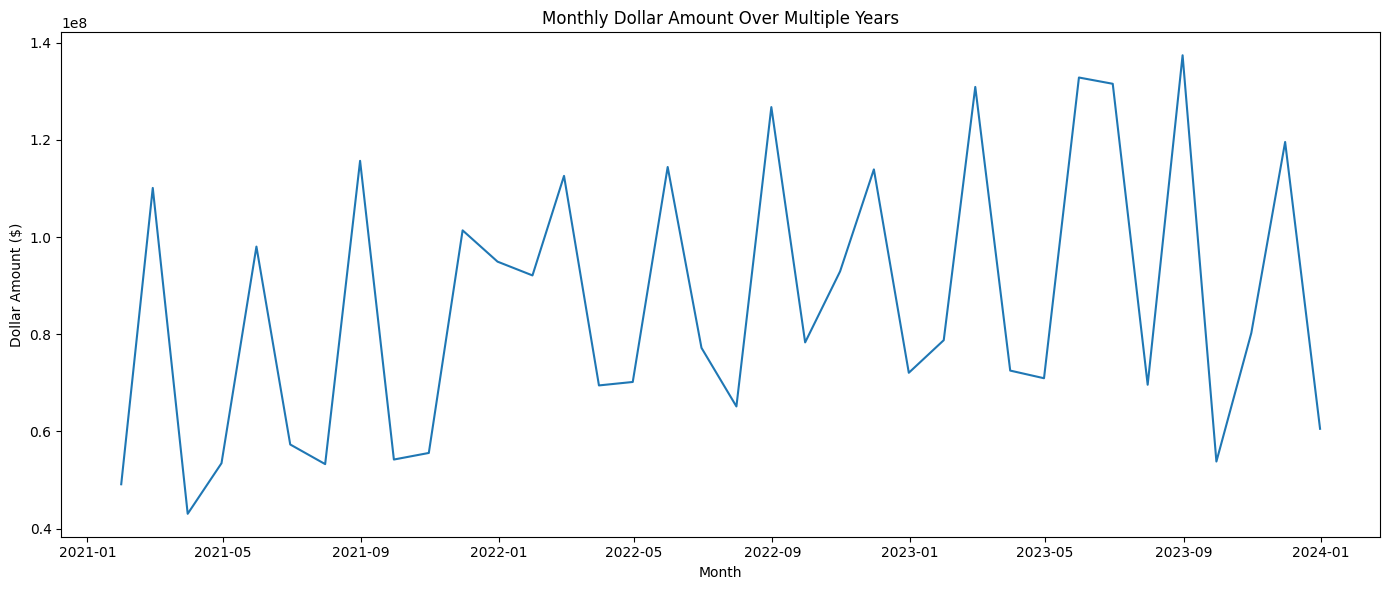

In [50]:
# optional: sort by date

# Aggregate by month across all years
df_monthly = (
    df
    .groupby(pd.Grouper(key='date_of_payment', freq='ME'))['total_amount_of_payment_us_dollars']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(data=df_monthly, x='date_of_payment', y='total_amount_of_payment_us_dollars')
plt.title("Monthly Dollar Amount Over Multiple Years")
plt.xlabel("Month")
plt.ylabel("Dollar Amount ($)")
plt.tight_layout()
plt.show()


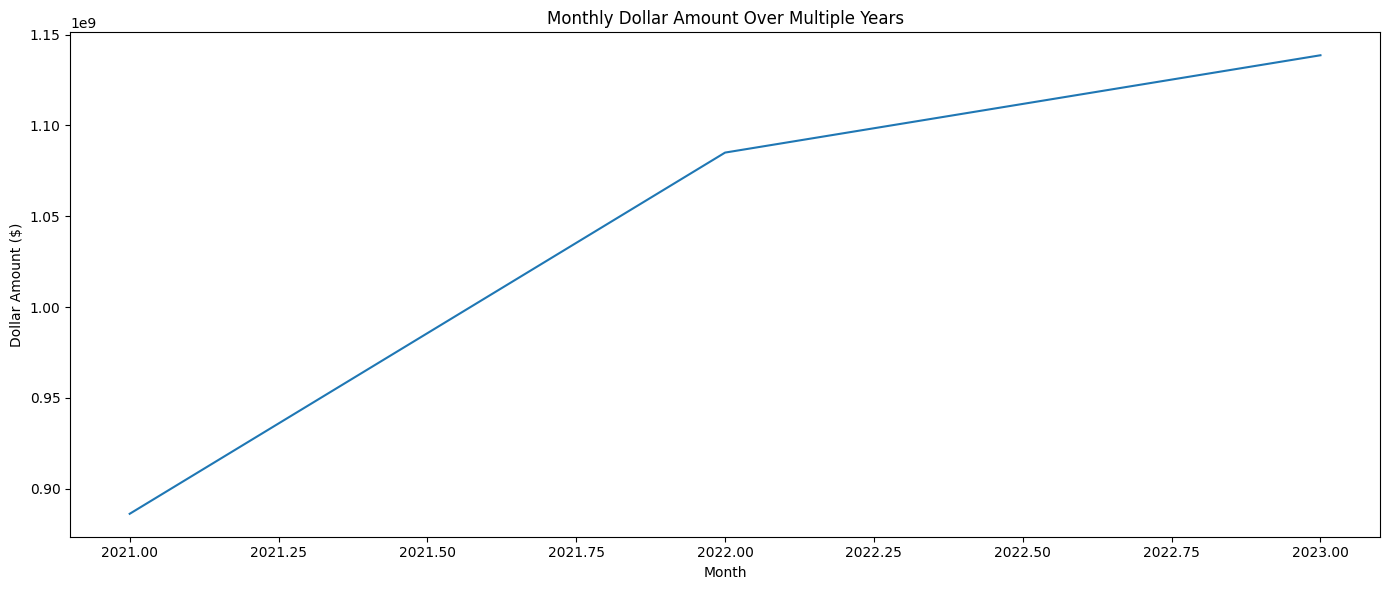

In [51]:
# optional: sort by date

# Aggregate by year across all years
df_yearly = (
    df
    .groupby("program_year")['total_amount_of_payment_us_dollars']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(data=df_yearly, x='program_year', y='total_amount_of_payment_us_dollars')
plt.title("Monthly Dollar Amount Over Multiple Years")
plt.xlabel("Month")
plt.ylabel("Dollar Amount ($)")
plt.tight_layout()
plt.show()


In [52]:
df['log_amount'] = np.log1p(df['total_amount_of_payment_us_dollars'])

df['z_log'] = df.groupby('applicable_manufacturer_or_applicable_gpo_making_payment_name')['log_amount'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df_outliers = df[df['z_log'] > 3]

df_outliers.sort_values(by='z_log', ascending=False)

,Unnamed: 0,change_type,covered_recipient_type,covered_recipient_profile_id,covered_recipient_npi,recipient_primary_business_street_address_line1,recipient_primary_business_street_address_line2,recipient_city,recipient_state,recipient_zip_code,...,recipient_region,excltype,num_exclusions_alltime,num_exclusion_types_alltime,fraud_flag,specialty_lvl1,specialty_lvl2,specialty_lvl3,log_amount,z_log
6255219,7479927,UNCHANGED,Covered Recipient Physician,163904,1619948270,200 1st St SW,NaN,Rochester,MN,55905.0,...,Midwest,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Internal Medicine,Gastroenterology,11.307597,23.000152
5436462,6499631,UNCHANGED,Covered Recipient Physician,163904,1619948270,200 1st St SW,NaN,Rochester,MN,55905.0,...,Midwest,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Internal Medicine,Gastroenterology,11.263541,22.878238
2975646,3553989,UNCHANGED,Covered Recipient Physician,163904,1619948270,200 1st St SW,NaN,Rochester,MN,55905.0,...,Midwest,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Internal Medicine,Gastroenterology,11.216472,22.747988
6254845,7479552,UNCHANGED,Covered Recipient Physician,163904,1619948270,200 1st St SW,NaN,Rochester,MN,55905.0,...,Midwest,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Internal Medicine,Gastroenterology,11.187098,22.666705
5630661,6735680,UNCHANGED,Covered Recipient Physician,515029,1326307430,505 Parnassus Avenue,NaN,San Francisco,CA,94117.0,...,West,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Pathology,Clinical Pathology/Laboratory Medicine,9.958260,19.266240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3430543,4103100,UNCHANGED,Covered Recipient Physician,295661,1528242336,1305 AIRPORT FWY,NaN,BEDFORD,TX,76021.0,...,South,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Internal Medicine,Clinical Cardiac Electrophysiology,7.129201,3.000125
1823836,2178219,UNCHANGED,Covered Recipient Physician,295661,1528242336,1305 AIRPORT FWY,NaN,BEDFORD,TX,76021.0,...,South,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Internal Medicine,Clinical Cardiac Electrophysiology,7.129201,3.000125
6298656,7531783,UNCHANGED,Covered Recipient Physician,824224,1194844019,676 N Saint Clair St Ste 950,NaN,CHICAGO,IL,60611.0,...,Midwest,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Obstetrics & Gynecology,Female Pelvic Medicine and Reconstructive Surgery,7.226936,3.000004
5159721,6175442,UNCHANGED,Covered Recipient Physician,1198769,1346570405,676 N SAINT CLAIR ST,SUITE 950,CHICAGO,IL,60611.0,...,Midwest,NaN,NaN,NaN,0,Allopathic & Osteopathic Physicians,Obstetrics & Gynecology,Female Pelvic Medicine and Reconstructive Surgery,7.226936,3.000004


In [53]:
fraud_only['log_amount'] = np.log1p(fraud_only['total_amount_of_payment_us_dollars'])

fraud_only['z_log'] = fraud_only.groupby('applicable_manufacturer_or_applicable_gpo_making_payment_name')['log_amount'].transform(
    lambda x: (x - x.mean()) / x.std()
)

fraud_outliers = fraud_only[fraud_only['z_log'] > 3]

fraud_outliers.sort_values(by='z_log', ascending=False)

,Unnamed: 0,change_type,covered_recipient_type,covered_recipient_profile_id,covered_recipient_npi,recipient_primary_business_street_address_line1,recipient_primary_business_street_address_line2,recipient_city,recipient_state,recipient_zip_code,...,recipient_region,excltype,num_exclusions_alltime,num_exclusion_types_alltime,fraud_flag,specialty_lvl1,specialty_lvl2,specialty_lvl3,log_amount,z_log
5042530,6033811,UNCHANGED,Covered Recipient Physician,152725,1366400798,700 S HENDERSON RD,NaN,KING OF PRUSSIA,PA,19406.0,...,Northeast,1128a1,1.0,1.0,1,Allopathic & Osteopathic Physicians,Orthopaedic Surgery,Orthopaedic Surgery of the Spine,6.819732,4.684067
2121116,2532684,UNCHANGED,Covered Recipient Physician,152725,1366400798,700 S HENDERSON RD,NaN,KING OF PRUSSIA,PA,19406.0,...,Northeast,1128a1,1.0,1.0,1,Allopathic & Osteopathic Physicians,Orthopaedic Surgery,Orthopaedic Surgery of the Spine,6.814828,4.678433
436916,526373,UNCHANGED,Covered Recipient Physician,281814,1205800257,1031 E KARSCH BLVD,NaN,FARMINGTON,MO,63640.0,...,Midwest,1128a3,1.0,1.0,1,Allopathic & Osteopathic Physicians,Internal Medicine,None,7.313887,3.403095
436928,526385,UNCHANGED,Covered Recipient Physician,281814,1205800257,1031 E KARSCH BLVD,NaN,FARMINGTON,MO,63640.0,...,Midwest,1128a3,1.0,1.0,1,Allopathic & Osteopathic Physicians,Internal Medicine,None,7.313887,3.403095
4294532,5142168,UNCHANGED,Covered Recipient Physician,281814,1205800257,1031 E KARSCH BLVD,NaN,FARMINGTON,MO,63640.0,...,Midwest,1128a3,1.0,1.0,1,Allopathic & Osteopathic Physicians,Internal Medicine,None,7.313887,3.403095
6070375,7262977,UNCHANGED,Covered Recipient Physician,111787,1477743094,462 N LINDEN DR,SUITE 234,BEVERLY HILLS,CA,90212.0,...,West,1128a3,1.0,1.0,1,Allopathic & Osteopathic Physicians,Plastic Surgery,None,4.990433,3.295345


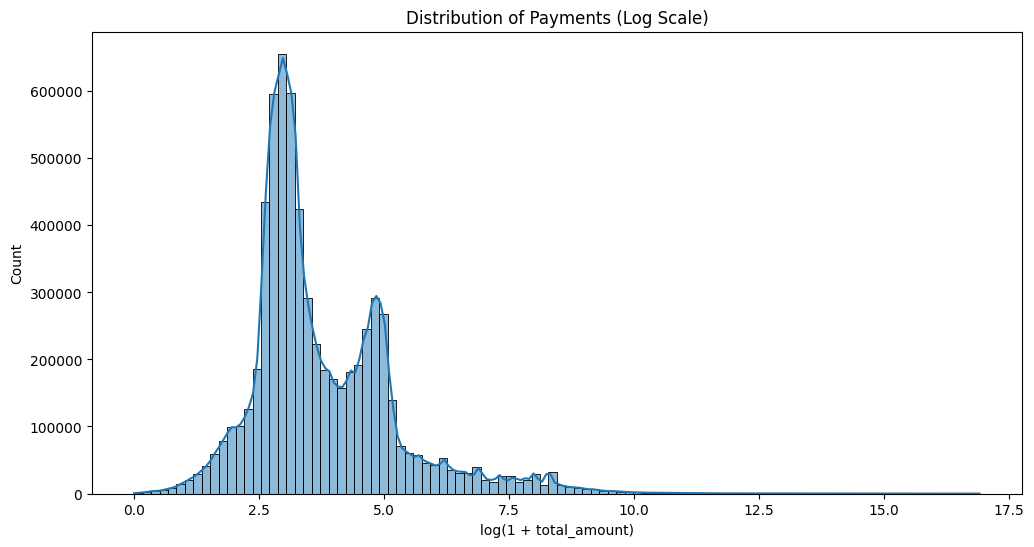

In [54]:
plt.figure(figsize=(12,6))
sns.histplot(df['log_amount'], bins=100, kde=True)

plt.title("Distribution of Payments (Log Scale)")
plt.xlabel("log(1 + total_amount)")
plt.ylabel("Count")
plt.show()

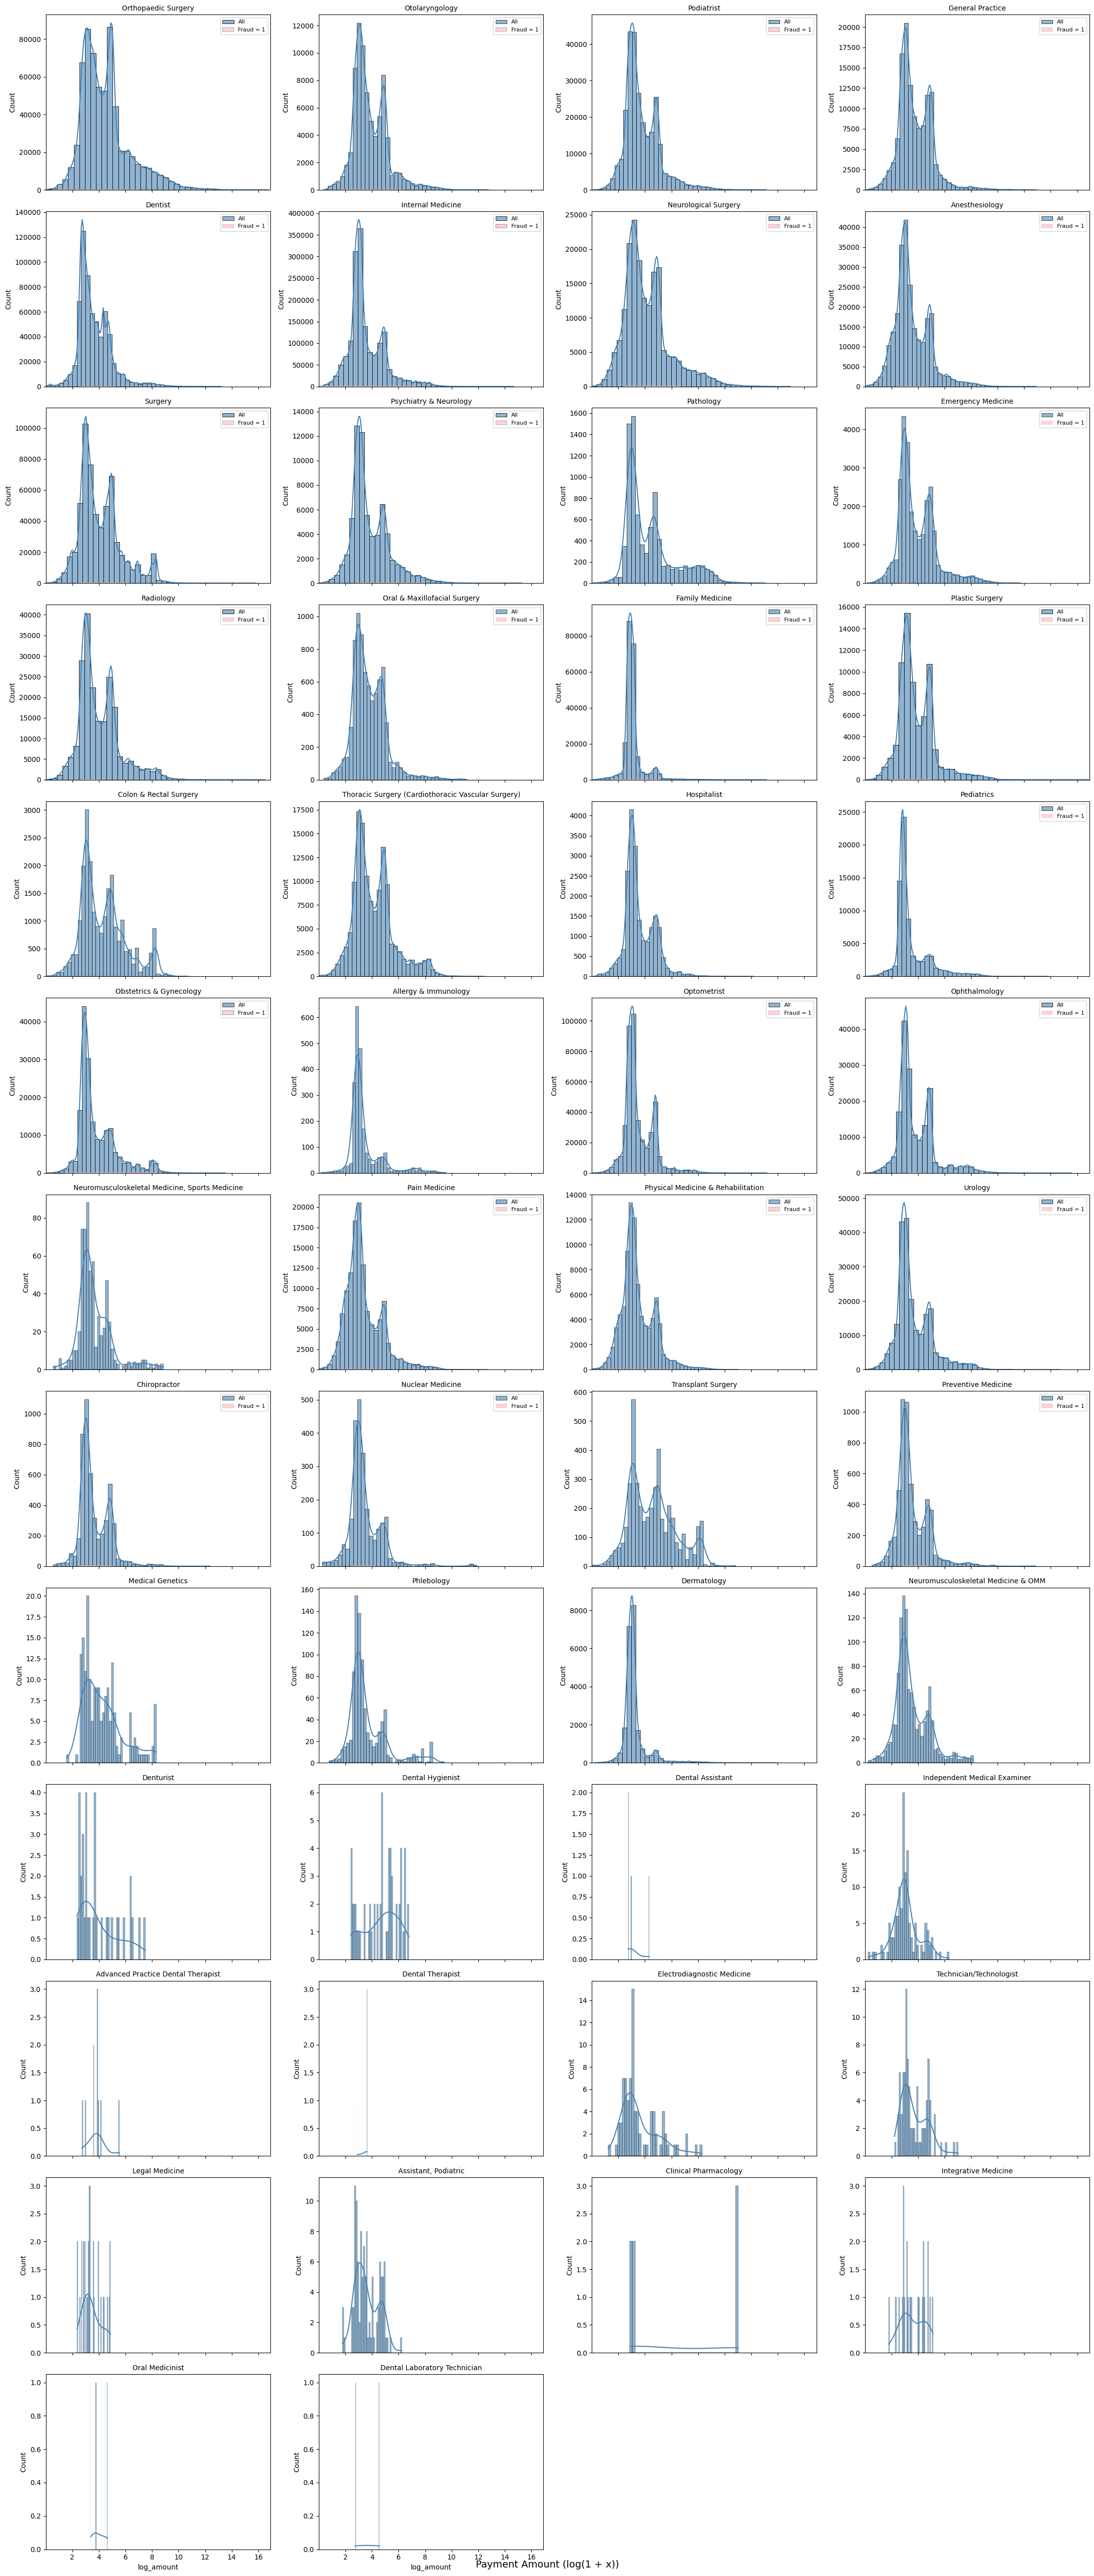

In [55]:
# unique specialties
specialties = df['specialty_lvl2'].dropna().unique()
n = len(specialties)

cols = 4
rows = int(np.ceil(n / cols))

# Pre-calc global x-limits so every subplot uses the same axis
xmin = df['log_amount'].min()
xmax = df['log_amount'].max()

fig, axes = plt.subplots(rows, cols, figsize=(22, 4*rows), sharex=True)
axes = axes.flatten()

for i, spec in enumerate(specialties):
    ax = axes[i]
    subset = df[df['specialty_lvl2'] == spec]

    # Normal distribution
    sns.histplot(
        subset['log_amount'], bins=40, kde=True,
        ax=ax, color='steelblue', alpha=0.6, label='All'
    )

    # Fraud overlay
    fraud_subset = subset[subset['fraud_flag'] == 1]

    if len(fraud_subset) > 0:
        sns.histplot(
            fraud_subset['log_amount'], bins=40, kde=True,
            ax=ax, color='pink', alpha=0.7, label='Fraud = 1'
        )

    ax.set_xlim(xmin, xmax)
    ax.set_title(spec, fontsize=10)
    ax.set_ylabel("Count")

    # Add legend only if there are fraud samples
    if len(fraud_subset) > 0:
        ax.legend(fontsize=8)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Shared label for all subplots
fig.supxlabel("Payment Amount (log(1 + x))", fontsize=14)

plt.tight_layout()
plt.show()

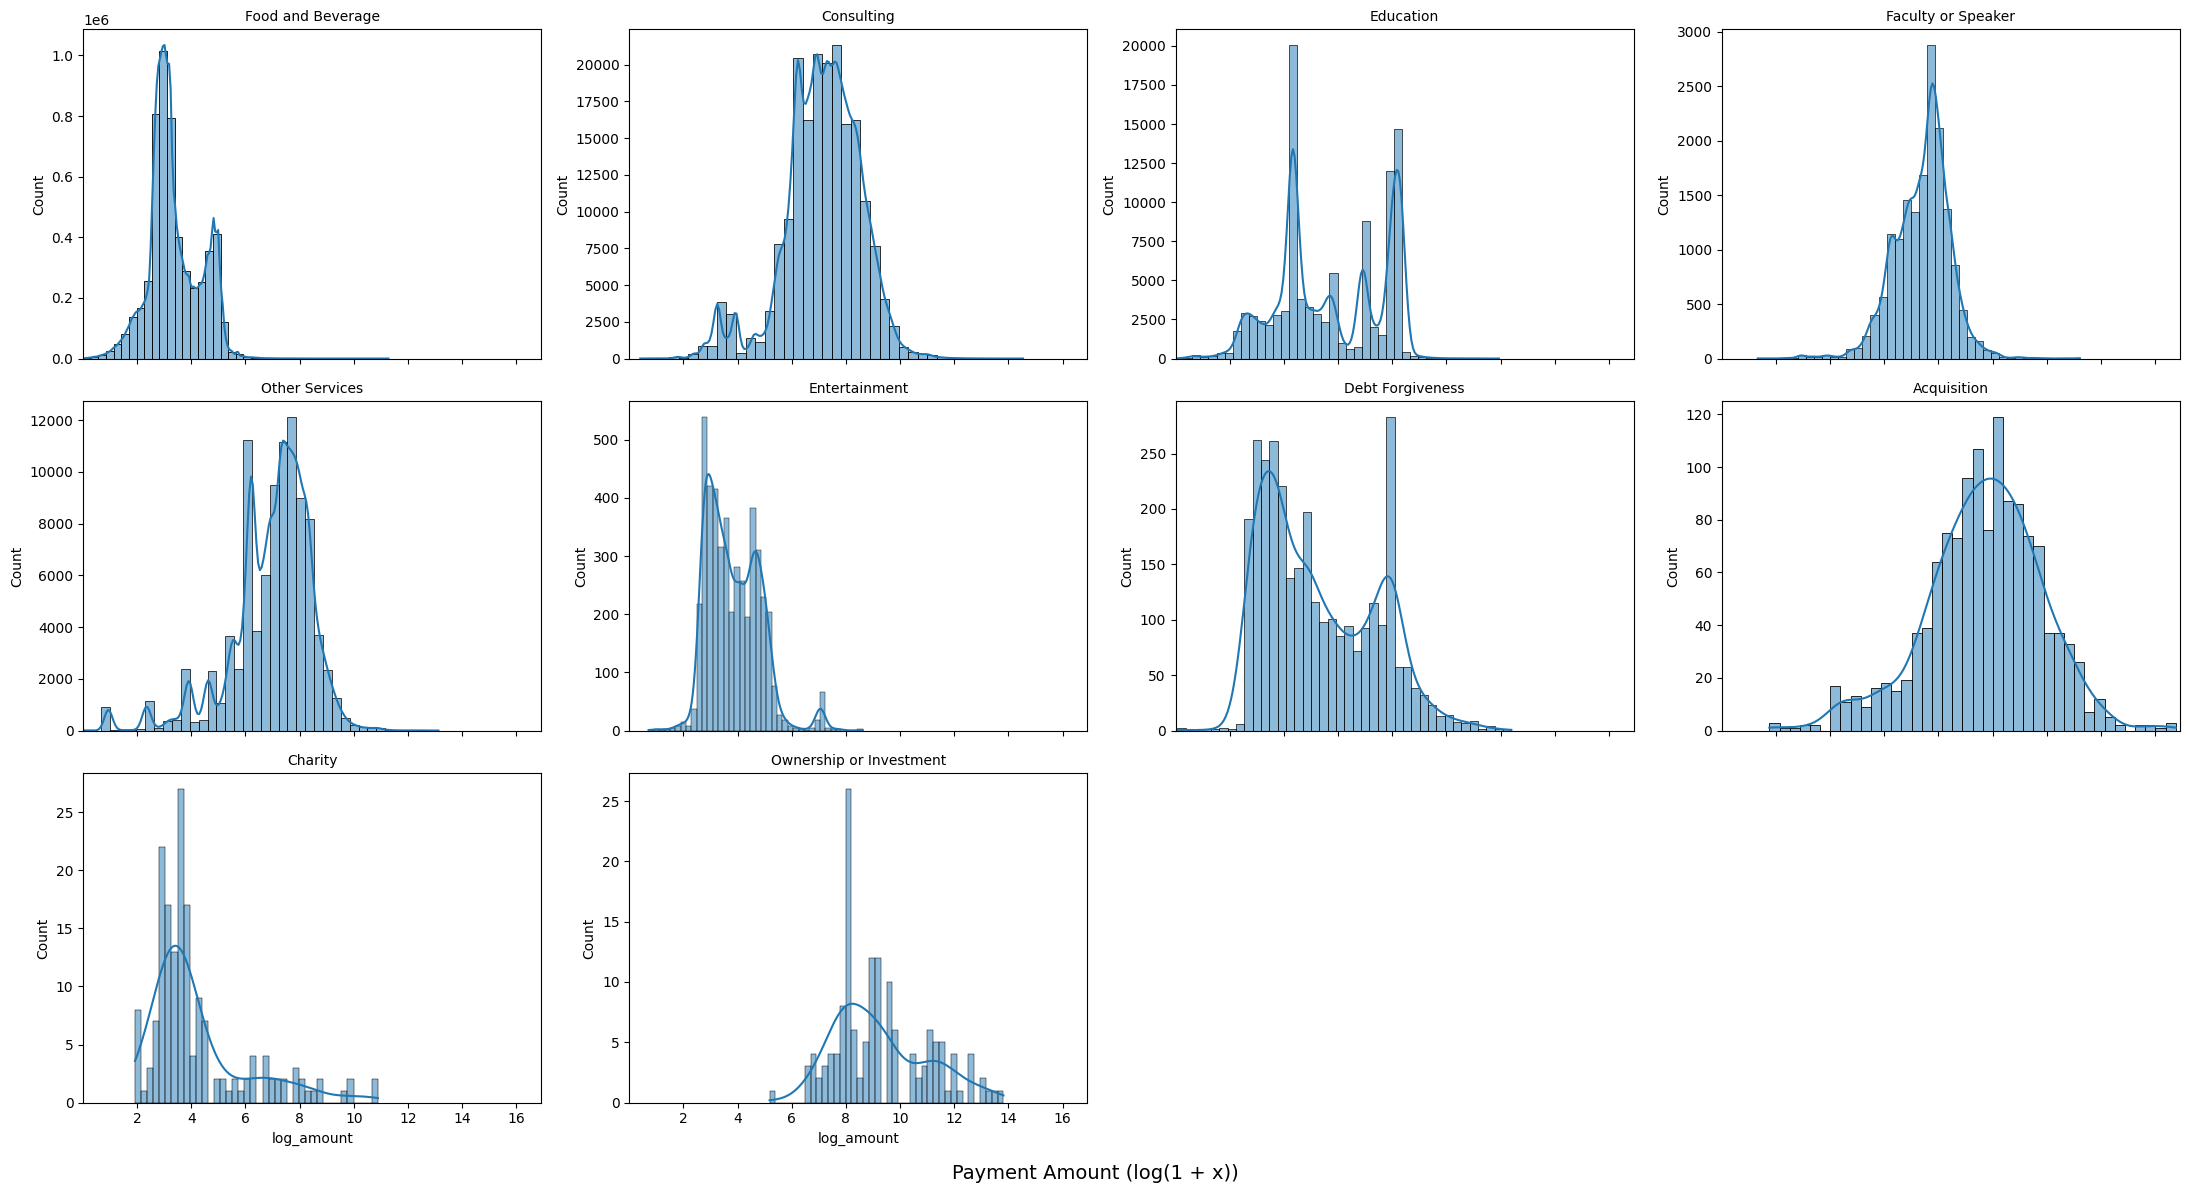

In [58]:
# unique payment natures
nature_descrs = df['nature_short_descr'].dropna().unique()
n = len(nature_descrs)
cols = 4
rows = int(np.ceil(n / cols))

# Pre-calc global x-limits so every subplot uses the same axis
xmin = df['log_amount'].min()
xmax = df['log_amount'].max()

fig, axes = plt.subplots(rows, cols, figsize=(22, 4*rows), sharex=True)
axes = axes.flatten()

for i, spec in enumerate(nature_descrs):
    ax = axes[i]
    subset = df[df['nature_short_descr'] == spec]

    sns.histplot(subset['log_amount'], bins=40, kde=True, ax=ax)

    ax.set_xlim(xmin, xmax)   # enforce global x-range
    ax.set_title(spec, fontsize=10)
    ax.set_ylabel("Count")

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Set ONE shared x-axis label for the whole figure
fig.supxlabel("Payment Amount (log(1 + x))", fontsize=14)

plt.tight_layout()
plt.show()